In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

In [42]:
Dt = pd.read_excel('1.3.3 Data.xlsx')
izmerenia=['d4 l50', 'd4 l70', 'd4 l90', 'd4 l40.5!', 'd5 l30', 'd5 l40', 'd5 l50', 'd5 l90', 'd5 l40.5!', 'd3 l30', 'd3 l50', 'd3 l30!']
for name in izmerenia:
    Dt.insert(0, name + ' Q', Dt[name + ' v'].div(Dt[name + ' t']))

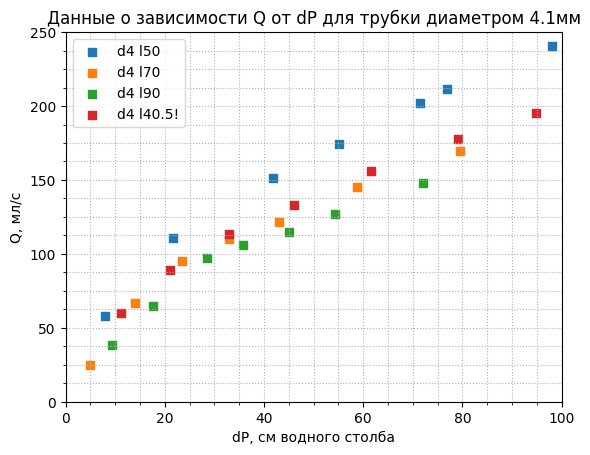

In [43]:
for name in izmerenia[0:4]:
    dp = Dt[name + ' dp']
    Q = Dt[name + ' Q']
    plt.scatter(dp, Q, marker=',', label=name)
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(12.5))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 250)
plt.xlim(0, 100)
plt.title('Данные о зависимости Q от dP для трубки диаметром 4.1мм')
plt.xlabel("dP, см водного столба")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

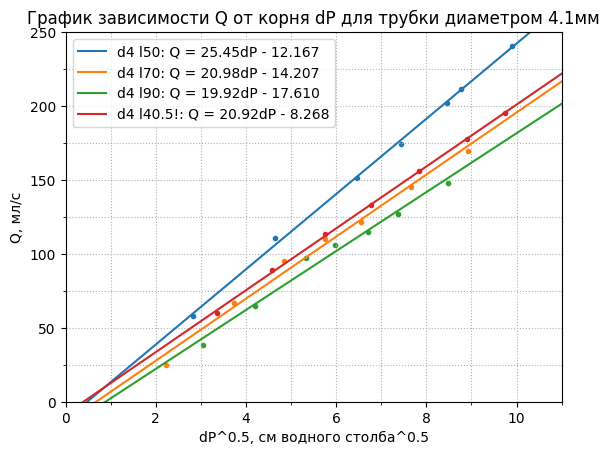

In [44]:
for name in izmerenia[0:4]:
    dp = Dt[name + ' dp']
    Q = Dt[name + ' Q']
    plt.scatter(dp.pow(0.5), Q, marker='.')
    coeffs = np.polyfit(dp.pow(0.5), Q, deg=1)
    poly_func = np.poly1d(coeffs)
    x = np.linspace(0, 11, 1000)
    y = poly_func(x)
    plt.plot(x, y, label=f"{name}: Q = {coeffs[0]:.2f}dP - {abs(coeffs[1]):.3f}")
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(25))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 250)
plt.xlim(0, 11)
plt.title('График зависимости Q от корня dP для трубки диаметром 4.1мм')
plt.xlabel("dP^0.5, см водного столба^0.5")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

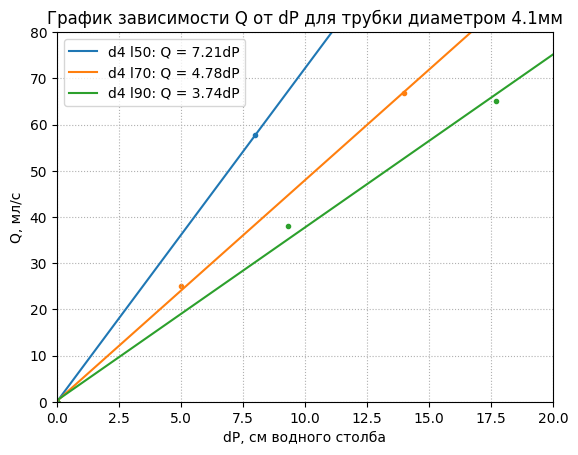

In [45]:
k4=[]
for name in izmerenia[0:3]:
    if name == 'd4 l70' or name == 'd4 l90':
        dp = [0, 0, 0, 0, 0]+list(Dt[name + ' dp'][0:2])
        Q = [0, 0, 0, 0, 0]+list(Dt[name + ' Q'][0:2])
    else:
        dp = [0, 0, 0, 0, 0]+list(Dt[name + ' dp'][0:1])
        Q = [0, 0, 0, 0, 0]+list(Dt[name + ' Q'][0:1])
    plt.scatter(dp, Q, marker='.')
    coeffs = np.polyfit(dp, Q, deg=1)
    poly_func = np.poly1d(coeffs)
    x = np.linspace(0, 20, 1000)
    y = poly_func(x)
    plt.plot(x, y, label=f"{name}: Q = {coeffs[0]:.2f}dP")
    k4.append(float(coeffs[0]))
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 80)
plt.xlim(0, 20)
plt.title('График зависимости Q от dP для трубки диаметром 4.1мм')
plt.xlabel("dP, см водного столба")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

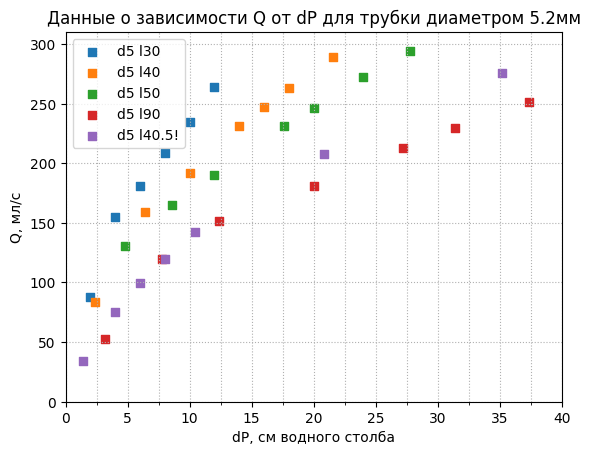

In [46]:
for name in izmerenia[4:9]:
    dp = Dt[name + ' dp']
    Q = Dt[name + ' Q']
    plt.scatter(dp, Q, marker=',', label=name)
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 310)
plt.xlim(0, 40)
plt.title('Данные о зависимости Q от dP для трубки диаметром 5.2мм')
plt.xlabel("dP, см водного столба")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

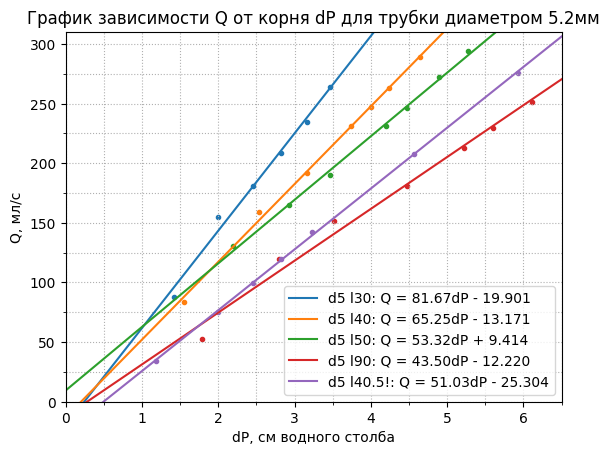

In [47]:
for name in izmerenia[4:9]:
    dp = Dt[name + ' dp'].pow(0.5)
    Q = Dt[name + ' Q']
    plt.scatter(dp, Q, marker='.')
    if name == 'd5 l30':
        coeffs = np.polyfit(dp[0:6], Q[0:6], deg=1)
    else:
        coeffs = np.polyfit(dp, Q, deg=1)
    poly_func = np.poly1d(coeffs)
    x = np.linspace(0, 6.5, 1000)
    y = poly_func(x)
    if name == 'd5 l50':
        plt.plot(x, y, label=f"{name}: Q = {coeffs[0]:.2f}dP + {coeffs[1]:.3f}")
    else:
        plt.plot(x, y, label=f"{name}: Q = {coeffs[0]:.2f}dP - {abs(coeffs[1]):.3f}")
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(25))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 310)
plt.xlim(0, 6.5)
plt.title('График зависимости Q от корня dP для трубки диаметром 5.2мм')
plt.xlabel("dP, см водного столба")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

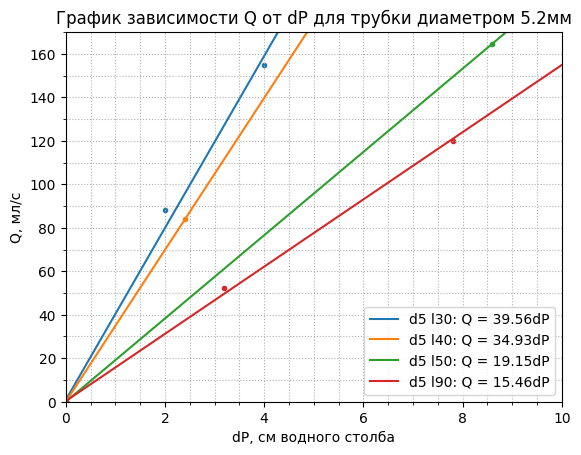

In [48]:
k5=[]
for name in izmerenia[4:8]:
    if name == 'd5 l30' or name == 'd5 l90':
        dp = [0, 0, 0, 0, 0]+list(Dt[name + ' dp'][0:2])
        Q = [0, 0, 0, 0, 0]+list(Dt[name + ' Q'][0:2])
    else:
        dp = [0, 0, 0, 0, 0]+list(Dt[name + ' dp'][0:1])
        Q = [0, 0, 0, 0, 0]+list(Dt[name + ' Q'][0:1])
    plt.scatter(dp, Q, marker='.')
    coeffs = np.polyfit(dp, Q, deg=1)
    poly_func = np.poly1d(coeffs)
    x = np.linspace(0, 20, 1000)
    y = poly_func(x)
    plt.plot(x, y, label=f"{name}: Q = {coeffs[0]:.2f}dP")
    k5.append(float(coeffs[0]))
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 170)
plt.xlim(0, 10)
plt.title('График зависимости Q от dP для трубки диаметром 5.2мм')
plt.xlabel("dP, см водного столба")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

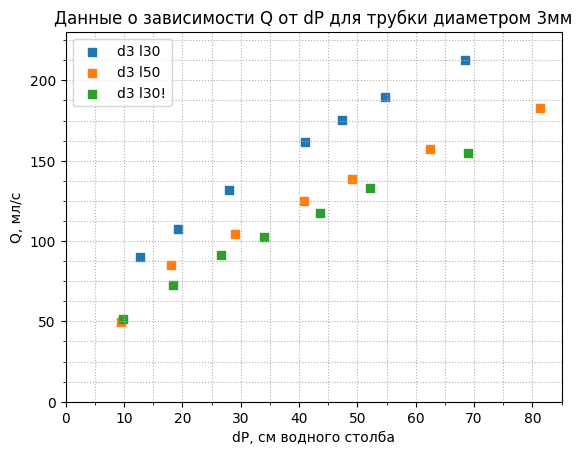

In [49]:
for name in izmerenia[9:]:
    dp = Dt[name + ' dp']
    Q = Dt[name + ' Q']
    plt.scatter(dp, Q, marker=',', label=name)
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(12.5))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 230)
plt.xlim(0, 85)
plt.title('Данные о зависимости Q от dP для трубки диаметром 3мм')
plt.xlabel("dP, см водного столба")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

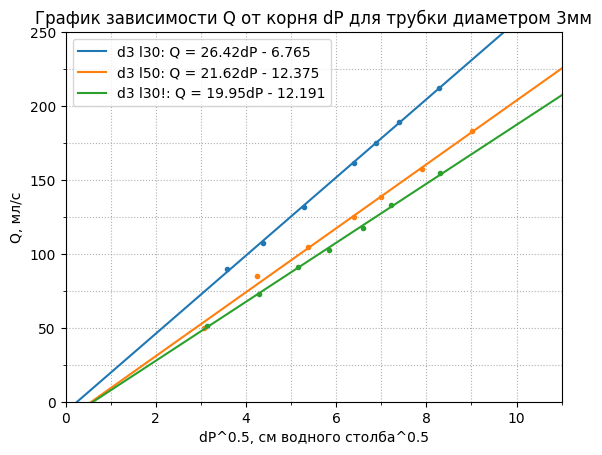

In [50]:
for name in izmerenia[9:]:
    dp = Dt[name + ' dp']
    Q = Dt[name + ' Q']
    plt.scatter(dp.pow(0.5), Q, marker='.')
    coeffs = np.polyfit(dp.pow(0.5), Q, deg=1)
    poly_func = np.poly1d(coeffs)
    x = np.linspace(0, 11, 1000)
    y = poly_func(x)
    plt.plot(x, y, label=f"{name}: Q = {coeffs[0]:.2f}dP - {abs(coeffs[1]):.3f}")
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(25))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 250)
plt.xlim(0, 11)
plt.title('График зависимости Q от корня dP для трубки диаметром 3мм')
plt.xlabel("dP^0.5, см водного столба^0.5")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

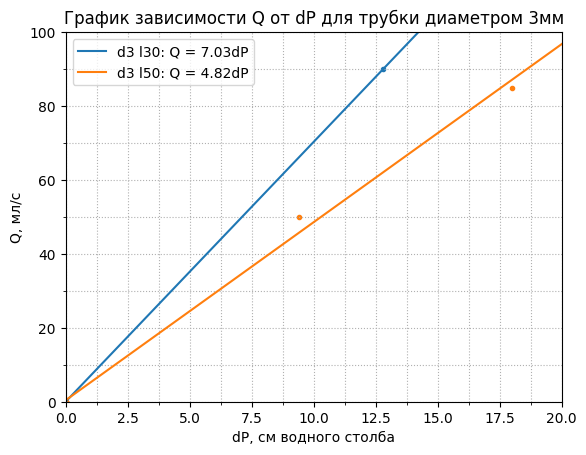

In [51]:
k3=[]
for name in izmerenia[9:11]:
    if name == 'd3 l50':
        dp = [0, 0, 0, 0, 0]+list(Dt[name + ' dp'][0:2])
        Q = [0, 0, 0, 0, 0]+list(Dt[name + ' Q'][0:2])
    else:
        dp = [0]+list(Dt[name + ' dp'][0:1])
        Q = [0]+list(Dt[name + ' Q'][0:1])
    plt.scatter(dp, Q, marker='.')
    coeffs = np.polyfit(dp, Q, deg=1)
    poly_func = np.poly1d(coeffs)
    x = np.linspace(0, 20, 1000)
    y = poly_func(x)
    plt.plot(x, y, label=f"{name}: Q = {coeffs[0]:.2f}dP")
    k3.append(float(coeffs[0]))
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1.25))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.ylim(0, 100)
plt.xlim(0, 20)
plt.title('График зависимости Q от dP для трубки диаметром 3мм')
plt.xlabel("dP, см водного столба")
plt.ylabel("Q, мл/с")
ax.legend()
plt.show()

In [52]:
print(k3, k4, k5)

l3=[0.3, 0.5]
l4=[0.5, 0.7, 0.9]
l5=[0.3, 0.4, 0.5, 0.9]
eta3=[]
eta4=[]
eta5=[]
for i in range(2):
    eta3.append(np.pi*9806700*((1.5/1000)**4)/8/l3[i]/k3[i])
for i in range(3):
    eta4.append((np.pi*9806700*((2.05/1000)**4)/8/l4[i]/k4[i]))
for i in range(4):
    eta5.append((np.pi*9806700*((2.6/1000)**4)/8/l5[i]/k5[i]))
print(eta3, eta4, eta5)

[7.030007949125594, 4.817650339992843] [7.2145442579795995, 4.781791035618371, 3.743433225764024] [39.55571363959105, 34.933943089430905, 19.148129423660265, 15.460087872305076]
[9.244229970456049e-06, 8.093614802598681e-06] [1.8854686403316634e-05, 2.031933948027537e-05, 2.0187643167128448e-05] [1.4830154944482382e-05, 1.2594141478238723e-05, 1.8381451761753615e-05, 1.2647995428830782e-05]
